In [1]:
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'
img_transform = transforms.Compose([ #transformação de imagem
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

#conjunto de dados de treinamento e validação
batch_size = 128
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=False)

In [2]:
class ConvAutoEncoder(nn.Module): #autoencoders convolucionais
  def __init__(self):
    super().__init__()
    self.encoder = nn.Sequential( # duas camadas convolucionais seguidas, por camadas de maxpooling
        nn.Conv2d(1, 32, 3, stride=3, padding=1), nn.ReLU(True),
        nn.MaxPool2d(2, stride=2),
        nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
        nn.MaxPool2d(2, stride=1)
    )
    self.decoder = nn.Sequential( # tres camadas convolucionais transpostas
        nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True),
        nn.ConvTranspose2d(32, 16, 5, stride=3, padding=1), nn.ReLU(True),
        nn.ConvTranspose2d(16, 1, 2, stride=2, padding=1), nn.Tanh()
    )
  def forward(self, x):
    x = self.encoder(x)
    x = self.decoder(x)
    return x
model = ConvAutoEncoder().to(device)
!pip install torch_summary
from torchsummary import summary
summary(model, (1,28,28)); # mostra o shape de saida de cada camada

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 64, 2, 2]            --
|    └─Conv2d: 2-1                       [-1, 32, 10, 10]          320
|    └─ReLU: 2-2                         [-1, 32, 10, 10]          --
|    └─MaxPool2d: 2-3                    [-1, 32, 5, 5]            --
|    └─Conv2d: 2-4                       [-1, 64, 3, 3]            18,496
|    └─ReLU: 2-5                         [-1, 64, 3, 3]            --
|    └─MaxPool2d: 2-6                    [-1, 64, 2, 2]            --
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-7              [-1, 32, 5, 5]            18,464
|    └─ReLU: 2-8                         [-1, 32, 5, 5]            --
|    └─ConvTranspose2d: 2-9              [-1, 16, 15, 15]          12,816
|    └─ReLU: 2-10                        [-1, 16, 15, 15]          --
|    └─ConvTranspose2d: 2-11             [-1, 1, 28, 28]           65
| 

In [3]:
def train_batch(input, model, criterion, optimizer): # defini a funcao de train_batch
  model.train()
  optimizer.zero_grad()
  output = model(input)
  loss = criterion(output, input)
  loss.backward()
  optimizer.step()
  return loss

In [4]:
@torch.no_grad()
def validate_batch(input, model, criterion):  # defini a funcao de validade_batch, onde avalia o modelo de um lote
  model.eval()
  output = model(input)
  loss = criterion(output, input)
  return loss

In [5]:
model = ConvAutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

In [6]:
num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs): # treina por 5 epocas
  N = len(trn_dl)
  for ix, (data, _) in enumerate(trn_dl): # treina o modelo para cada lote e redefini a perda do treinamento
    loss = train_batch(data, model, criterion, optimizer)
    log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

  N = len(val_dl)
  for ix, (data, _) in enumerate(val_dl):
    loss = validate_batch(data, model, criterion)
    log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')

  log.report_avgs(epoch+1)

EPOCH: 1.000  trn_loss: 0.279  val_loss: 0.111  (56.68s - 226.71s remaining)
EPOCH: 2.000  trn_loss: 0.091  val_loss: 0.079  (96.90s - 145.35s remaining)
EPOCH: 3.000  trn_loss: 0.073  val_loss: 0.069  (133.14s - 88.76s remaining)
EPOCH: 4.000  trn_loss: 0.066  val_loss: 0.063  (169.79s - 42.45s remaining)
EPOCH: 5.000  trn_loss: 0.061  val_loss: 0.059  (207.02s - 0.00s remaining)


100%|██████████| 106/106 [00:00<00:00, 941.48it/s]


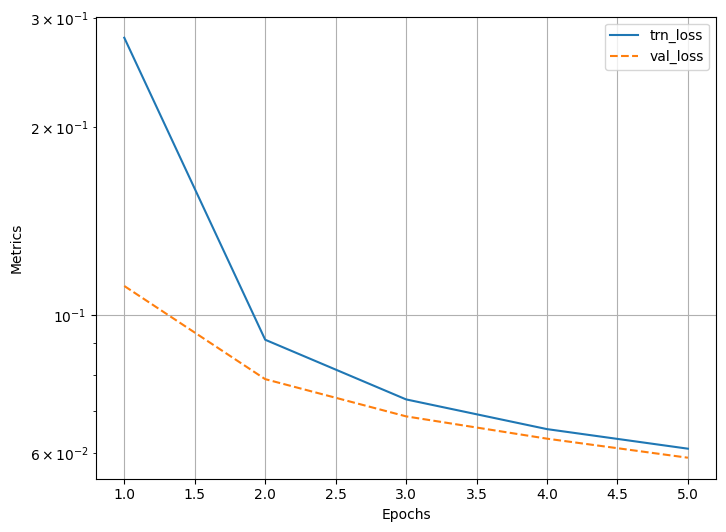

In [7]:
log.plot_epochs(log=True) # exibe imagem

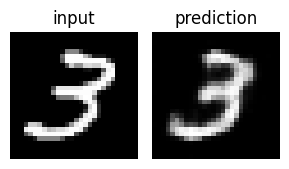

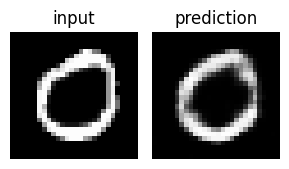

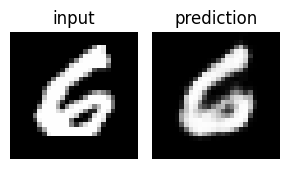

In [8]:
import matplotlib.pyplot as plt
for _ in range(3): # é selecionado 3 imagens para ser exibida e reconstruida
  ix = np.random.randint(len(val_ds))
  im, _ = val_ds[ix]
  _im = model(im[None])[0]
  fig, ax = plt.subplots(1, 2, figsize=(3,3))
  show(im[0], ax=ax[0], title='input')
  show(_im[0], ax=ax[1], title='prediction')
  plt.tight_layout()
  plt.show()

In [9]:
latent_vectors = []
classes = []

In [10]:
for im,clss in val_dl:
  # pega só a representação comprimida
  latent_vectors.append(model.encoder(im).view(len(im),-1))
  classes.extend(clss)

In [11]:
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy()

In [12]:
from sklearn.manifold import TSNE
tsne = TSNE(2)

In [13]:
clustered = tsne.fit_transform(latent_vectors)

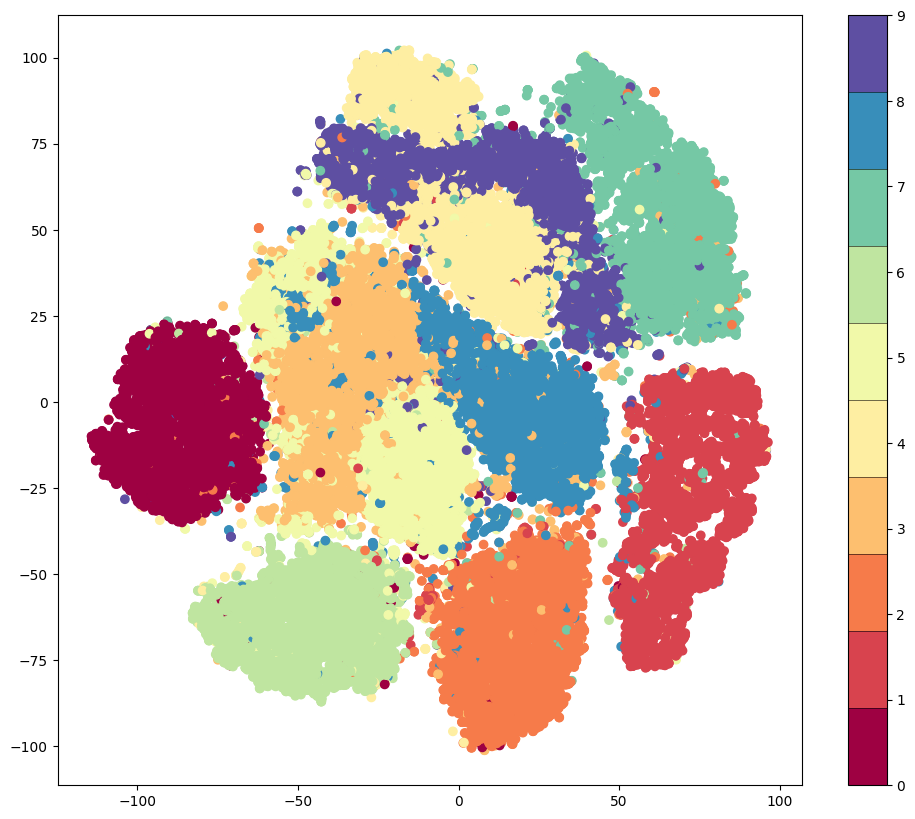

In [14]:
fig = plt.figure(figsize=(12,10))
cmap = plt.get_cmap('Spectral', 10)
plt.scatter(*zip(*clustered), c=classes, cmap=cmap)  # cada ponto colorido por classe, se o autoencoder aprendeu
plt.colorbar(drawedges=True)

In [15]:
latent_vectors = []
classes = []
for im, clss in val_dl:
  latent_vectors.append(model.encoder(im).view(im.shape[0], -1))
  classes.extend(clss)
latent_vectors = torch.cat(latent_vectors).cpu().detach().numpy()

In [16]:
rand_vectors = []
for col in latent_vectors.transpose(1,0):  # transpõe pra iterar coluna por coluna
  mu, sigma = col.mean(), col.std()
  rand_vectors.append(sigma*torch.randn(1,100) + mu)  # gera vetores aleatórios de 1 a 100


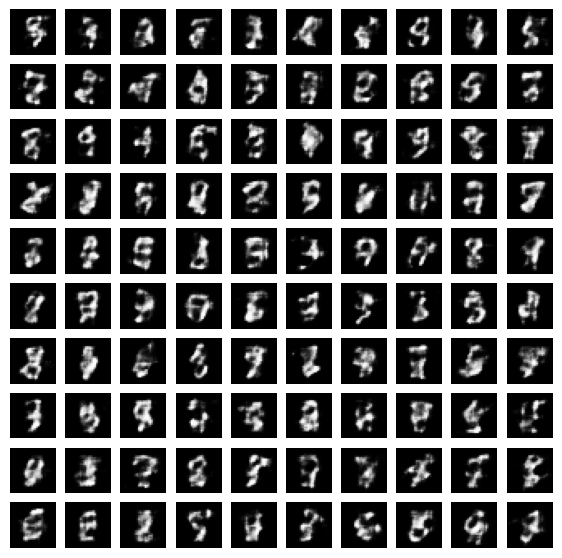

In [17]:
rand_vectors = torch.cat(rand_vectors).transpose(1,0).to(device)
fig, ax = plt.subplots(10,10,figsize=(7,7)); ax = iter(ax.flat)
for p in rand_vectors:
  img = model.decoder(p.reshape(64,2,2)).view(28,28)  # é usado o modulo decodificador para gerar novas imagens
  show(img, ax=next(ax))